In [1]:
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import torchmetrics

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np




In [2]:
height = 64
width = 64
batch_size = 32

transform = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.Grayscale(num_output_channels=1), 
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder("data/train", transform=transform)
test_dataset = datasets.ImageFolder("data/test", transform=transform)


In [3]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [4]:
X_sample, y_sample = train_dataset[0]
print(f"sample shape: {X_sample.shape}")
print(f"sample dtype: {X_sample.dtype}")

print(f"Label of first sample: {train_dataset.classes[y_sample]}")

n_labels = len(train_dataset.classes) 

sample shape: torch.Size([1, 64, 64])
sample dtype: torch.float32
Label of first sample: paper


In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

torch.manual_seed(42)
model = ImageClassifier(n_inputs= height * width, n_hidden1=300, n_hidden2=100,
                        n_classes=n_labels).to(device)




In [6]:
#training the model 
def train(model, optimizer, criterion, train_loader, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        mean_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}")

#train the model 
learning_rate = 0.001
n_epochs = 100
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
xentropy = nn.CrossEntropyLoss()


train(model, optimizer, xentropy, train_loader, n_epochs)





Epoch 1/100, Loss: 1.0985
Epoch 2/100, Loss: 1.0971
Epoch 3/100, Loss: 1.0963
Epoch 4/100, Loss: 1.0956
Epoch 5/100, Loss: 1.0950
Epoch 6/100, Loss: 1.0947
Epoch 7/100, Loss: 1.0940
Epoch 8/100, Loss: 1.0937
Epoch 9/100, Loss: 1.0932
Epoch 10/100, Loss: 1.0927
Epoch 11/100, Loss: 1.0924
Epoch 12/100, Loss: 1.0920
Epoch 13/100, Loss: 1.0914
Epoch 14/100, Loss: 1.0912
Epoch 15/100, Loss: 1.0907
Epoch 16/100, Loss: 1.0903
Epoch 17/100, Loss: 1.0898
Epoch 18/100, Loss: 1.0895
Epoch 19/100, Loss: 1.0889
Epoch 20/100, Loss: 1.0885
Epoch 21/100, Loss: 1.0879
Epoch 22/100, Loss: 1.0874
Epoch 23/100, Loss: 1.0871
Epoch 24/100, Loss: 1.0865
Epoch 25/100, Loss: 1.0860
Epoch 26/100, Loss: 1.0855
Epoch 27/100, Loss: 1.0851
Epoch 28/100, Loss: 1.0844
Epoch 29/100, Loss: 1.0839
Epoch 30/100, Loss: 1.0835
Epoch 31/100, Loss: 1.0829
Epoch 32/100, Loss: 1.0823
Epoch 33/100, Loss: 1.0816
Epoch 34/100, Loss: 1.0810
Epoch 35/100, Loss: 1.0805
Epoch 36/100, Loss: 1.0800
Epoch 37/100, Loss: 1.0791
Epoch 38/1

Confusion Matrix:
[[114  28  40]
 [ 28 103  51]
 [ 40  45  96]]

Classification Report:
              precision    recall  f1-score   support

       paper       0.63      0.63      0.63       182
        rock       0.59      0.57      0.58       182
    scissors       0.51      0.53      0.52       181

    accuracy                           0.57       545
   macro avg       0.57      0.57      0.57       545
weighted avg       0.58      0.57      0.57       545



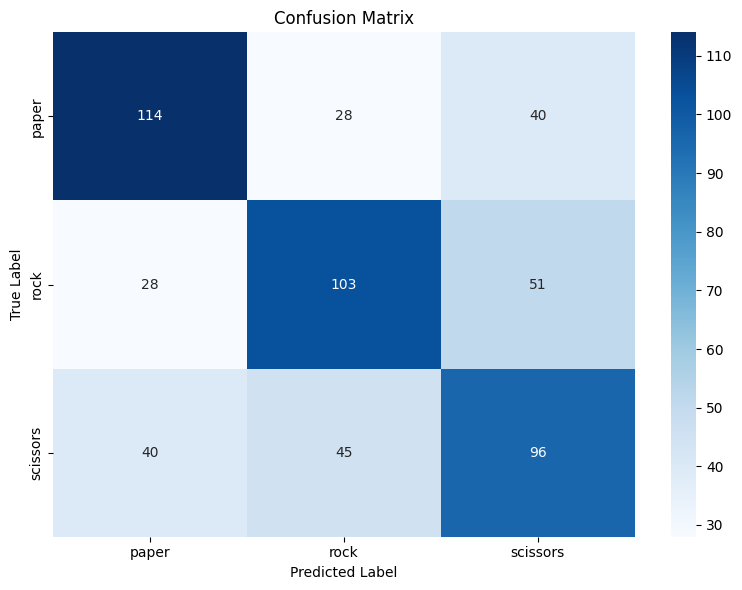


Test Accuracy: 0.5743


In [7]:
# Evaluate the model on test data
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# Print classification report
class_names = test_dataset.classes  # ['paper', 'rock', 'scissors']
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Calculate and print accuracy
accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"\nTest Accuracy: {accuracy:.4f}")